In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import linregress
import itertools as it
from matplotlib import rcParams
import matplotlib.colors as mcolors
from utils.analysis import uq_get_obs, uq_get_sim
import pandas as pd
from matplotlib.lines import Line2D


rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 14

pft_names = ['Spruce', 'Tamarack', 'Shrub']

outdir = os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 'extract')

chambers_ordered = {
    'amb': ['P07', 'P06', 'P20', 'P13', 'P08', 'P17'],
    'elev': ['P19', 'P11', 'P04', 'P16', 'P10']
}

In [2]:
# the dimensions are:
#   N sims x VAR_LIST x (amb, elev) x (mean, mean_std, slope, ts * slope_std)
prefix_list_uq = ['UQ_20231118', 'UQ_20240112'] # , 'UQ_20240312_test20241017']
N_list = [4000, 4000, 4000]
BLOCK_LIST = [200, 200, 200]
VAR_LIST = ['AGBiomass_Spruce', 'AGBiomass_Tamarack', 'AGBiomass_Shrub',
            'AGNPPtoBiomass_Spruce', 'AGNPPtoBiomass_Tamarack', 'AGNPPtoBiomass_Shrub',
            'AGNPP_Spruce', 'AGNPP_Tamarack', 'AGNPP_Shrub', 'NPP_moss',
            'BGNPP_TreeShrub', 'BGtoAG_TreeShrub', 'NPP', 'HR', 'NEE']
VAR_SUBSET =  ['AGNPP_Spruce','AGNPP_Tamarack','AGNPP_Shrub', 'NPP_moss',
               'BGNPP_TreeShrub','NPP','HR']

In [3]:
# the dimensions are:
#   N sims x VAR_LIST x (amb, elev) x (mean, mean_std, slope, ts * slope_std)
prefix_list_uq = ['UQ_20231118', 'UQ_20240112'] # , 'UQ_20240312_test20241017']
N_list = [4000, 4000, 4000]
BLOCK_LIST = [200, 200, 200]

collection_obs = uq_get_obs(VAR_SUBSET)

collection_sim = {}
for N, BLOCK, prefix in zip(N_list, BLOCK_LIST, prefix_list_uq):
    collect = np.empty([N, len(VAR_LIST), 2, 4], float)
    for b in range(0, N // BLOCK):
        collect[(b*BLOCK):((b + 1)*BLOCK), :, :, :] = np.load(os.path.join(
            os.environ['PROJDIR'], 'ELM_Nutrients', 'output', "extract", prefix,
            f"ensemble_collection_part{b:03g}.bin"), allow_pickle=True)[:, 1:, :, :] # TEMPORARY
    # convert Inf's to NaN
    collect = np.where(~((collect == np.inf) | (collect == -np.inf)), collect, np.nan)

    collection_sim[prefix] = collect

In [4]:
# Make a nicer graph that overlays the top 10 best runs of each prefix_list
sub1 = np.arange(10)
sub2 = np.arange(10,14)
xticklabels = {
    0: [var.replace('_','$_{')+'}$'+f' {co2}' for var in VAR_SUBSET[:5] \
        for co2 in ['', 'CO2']],
    1: [var.replace('_',' ')+f' {co2}' for var in VAR_SUBSET[5:] \
        for co2 in ['', 'CO2']],
}
ind_list = [] # the index to VAR_SUBSET that we are interested in
for i,var in enumerate(VAR_LIST):
    if var in VAR_SUBSET:
        ind_list.append(i)
ind_list = np.array(ind_list)

# (note: the index values is ensemble_id minus one, because Python index starts
#  from 0, and ensemble id starts from 1)
n_best_ind = 40
best_ind = {'UQ_20231118': 3066, 'UQ_20240107': 1484, 'UQ_20240112': 1943}
#best_ind = {'UQ_20231118': 1180, 'UQ_20240107': 1740, 'UQ_20240112': 1943}


#
obs_mean = collection_obs.values.reshape(-1, 2, 4)[:, :, 0]
obs_mean_std = collection_obs.values.reshape(-1, 2, 4)[:, :, 1]
obs_slope = collection_obs.values.reshape(-1, 2, 4)[:, :, 2]
obs_slope_std = collection_obs.values.reshape(-1, 2, 4)[:, :, 3]


#
sim_mean = {}
sim_mean_std = {}
sim_slope = {}
sim_slope_std = {}
for p, prefix in enumerate(prefix_list_uq):
    # the 2 is ACO2 and ECO2
    sim_mean[prefix] = collection_sim[prefix][best_ind[prefix], ind_list, :][:,:,0]
    sim_mean_std[prefix] = collection_sim[prefix][best_ind[prefix], ind_list, :][:,:,1]
    sim_slope[prefix] = collection_sim[prefix][best_ind[prefix], ind_list, :][:,:,2]
    sim_slope_std[prefix] = collection_sim[prefix][best_ind[prefix], ind_list, :][:,:,3]

#
obs_data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Nutrients', 'output', 'extract',
                                    'extract_obs_productivity.csv'), index_col = [0, 1])
# - restrict to pre-2021
obs_data = obs_data.loc[obs_data.index.get_level_values('Year') <= 2021, :]
# - re-order
t2m_obs = obs_data.loc[:, 'Tair']
obs_data = obs_data.loc[:, VAR_SUBSET]['AGNPP_Shrub']

In [5]:
labs = 'abcd'
clist = ['#1b249e', '#ff0000']
lss = ["-", "--"]
fcs = ["k", "none"]

ind_agnpp_shrub = np.where([x=='AGNPP_Shrub' for x in VAR_SUBSET])[0]

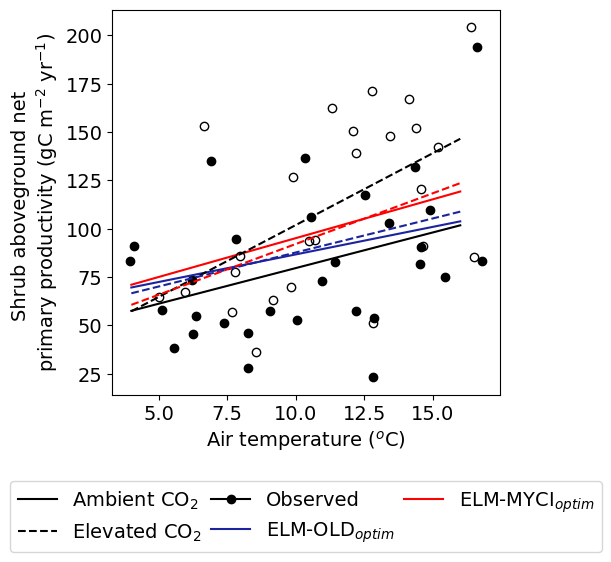

In [23]:
fig, ax = plt.subplots(figsize=(5, 5))
for i, co2 in enumerate(['amb', 'elev']):
    t_ = t2m_obs.loc[chambers_ordered[co2]]

    ax.plot(t_, obs_data.loc[chambers_ordered[co2]], 'ok', markerfacecolor=fcs[i])

    x = np.linspace(4, 16, 50)  # finer grid for a smooth band
    tmean = np.mean(t_)

    # --- Observed regression line + uncertainty ---
    slope = obs_slope[ind_agnpp_shrub, i]
    slope_std = obs_slope_std[ind_agnpp_shrub, i]
    mean_ = obs_mean[ind_agnpp_shrub, i]
    mean_std = obs_mean_std[ind_agnpp_shrub, i]

    y = mean_ + slope * (x - tmean)
    y_std = np.sqrt(mean_std**2 + (x - tmean)**2 * slope_std**2)

    ax.plot(x, y, 'k', ls=lss[i])
    #ax.fill_between(x, y - y_std, y + y_std, color='k', alpha=0.1-0.05*i, lw=0)

    # --- Simulated regression lines + uncertainty ---
    for prefix, c in zip(prefix_list_uq, clist):
        slope = sim_slope[prefix][ind_agnpp_shrub, i]
        slope_std = sim_slope_std[prefix][ind_agnpp_shrub, i]
        mean_ = sim_mean[prefix][ind_agnpp_shrub, i]
        mean_std = sim_mean_std[prefix][ind_agnpp_shrub, i]

        y = mean_ + slope * (x - tmean)
        y_std = np.sqrt(mean_std**2 + (x - tmean)**2 * slope_std**2)

        ax.plot(x, y, color=c, ls=lss[i])
        #ax.fill_between(x, y - y_std, y + y_std, color=c, alpha=0.1-0.05*i, lw=0)

ax.set_xlabel('Air temperature ($^o$C)')
ax.set_ylabel('Shrub aboveground net \nprimary productivity (gC m$^{-2}$ yr$^{-1}$)')

legend_elements = [
    Line2D([0], [0], color='k', ls='-', label='Ambient CO$_2$'),
    Line2D([0], [0], color='k', ls='--', label='Elevated CO$_2$'),
    Line2D([0], [0], color='k', marker='o', ls='-', markerfacecolor='k', label='Observed'),
    Line2D([0], [0], color=clist[0], ls='-', label='ELM-OLD$_{optim}$'),
    Line2D([0], [0], color=clist[1], ls='-', label='ELM-MYCI$_{optim}$'),
]

ax.legend(handles=legend_elements, ncols=3, loc='upper center', bbox_to_anchor=(0.5, -0.2), columnspacing=.5)
